In [10]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

# Organ


In [11]:
# First of all, we read the audio file using the given function readwav:
filename = "./wav_files/note_1.wav"
rate, data = readwav(filename)
# The way it is implemented, readwaw reads a wav file and returns two things:
# a float that contains the sampling rate of the signal,
# and an array that contains the actual data, meaning the intensity of the signal.
# The array is a matrix with two columns if the audio file was originally stereo instead of mono, so each column is a channel.
# The function manages to handle both 8bit signals and 24bit signals

# Let's print the rate of the chosen file:
print(rate) # the measure unit is Hertz

# Let's check whether the file was stereo or mono:
print(data.shape) # either there is no second column (mono) or there are two columns (stereo)

time = np.linspace(0, data.shape[0], data.shape[0], endpoint = False) # just a counter index for now
print(time)
time /= rate # Measure unit is now seconds

48000
(332193, 2)
[0.00000e+00 1.00000e+00 2.00000e+00 ... 3.32190e+05 3.32191e+05
 3.32192e+05]


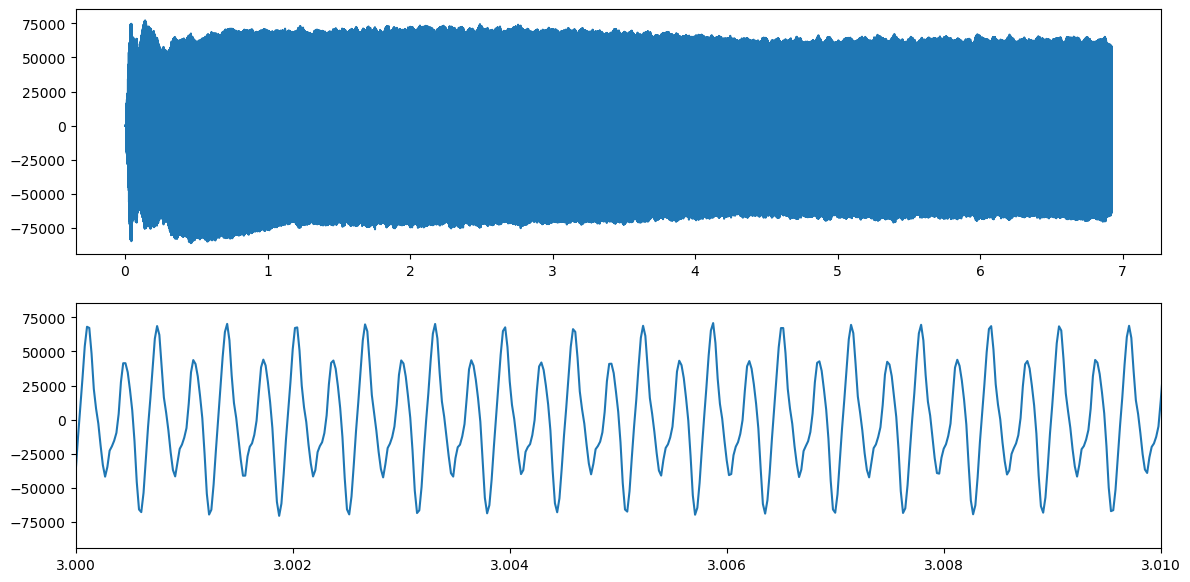

In [12]:
# Let's try visualizing the actual signal to get an idea:
figure, axes = plt.subplots(2, 1, figsize=(14, 7))
ax = axes[0]
ax.plot(time, data[:,0])

ax = axes[1]
ax.plot(time, data[:,0])
ax.set_xlim(3.0, 3.01)

plt.show()

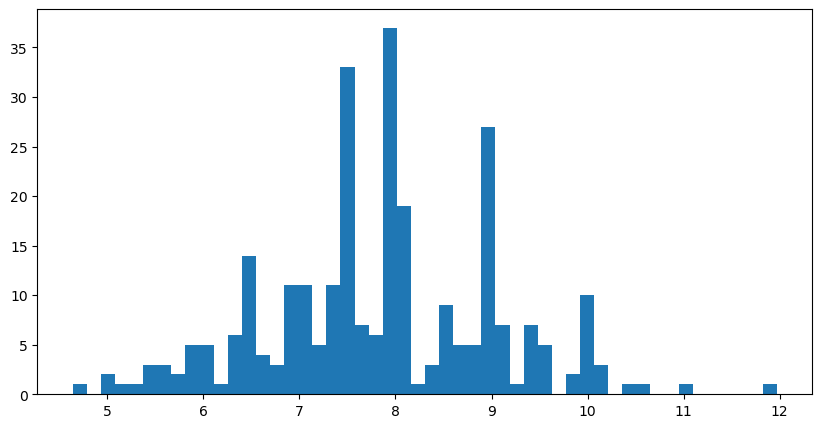

In [18]:
# Now we are curios to see the distribution of lengths of the signals, in the sense that we wonder if they're all
# 7 seconds long or something.

lengths = []
for i in range(1, 281):
    filename = "./wav_files/note_{}.wav".format(i)
    rate, data = readwav(filename)
    time = np.linspace(0, data.shape[0], data.shape[0], endpoint = False)
    time /= rate
    lengths.append(np.max(time))

plt.figure(figsize = (10, 5))
plt.hist(lengths, bins=50)
plt.show()
# Lengths go from 4s to 12s excluded, let's say

(0.0, 7.0)

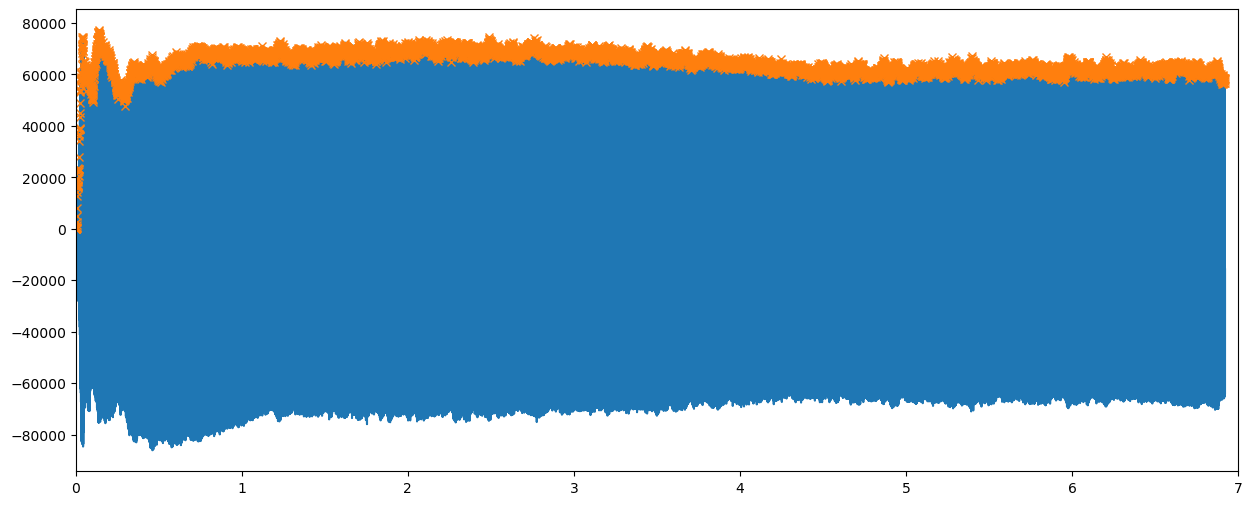

In [4]:
#calcolo i massimi del segnale
peaks, _ = scipy.signal.find_peaks(array[:,0], height=0.1, distance=20)
plt.figure(figsize=(15,6))
plt.plot(time, array[:,0])
plt.plot(time[peaks], array[peaks,0], "x")
plt.xlim(0,7)

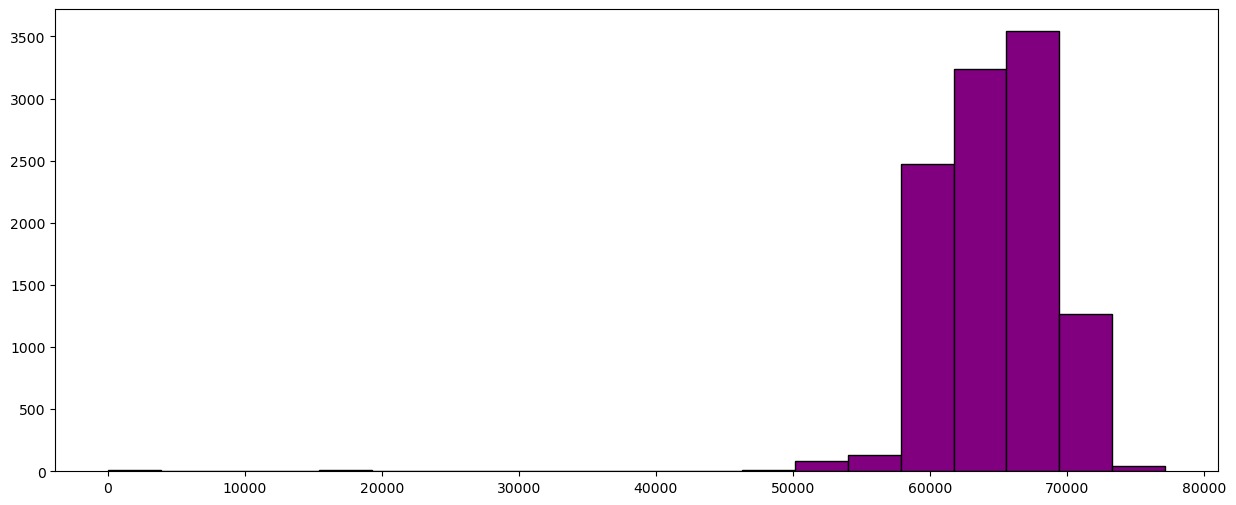

ModeResult(mode=np.int32(61275), count=np.int64(7))


In [5]:
# istogramma dei valori dei massimi del segnale
plt.figure(figsize=(15,6))
plt.hist(array[peaks,0], bins=20, color='purple', edgecolor='black')
plt.show()

#prendo valore più frequente degll'isotgramma
from scipy import stats
mode = stats.mode(array[peaks,0])
print(mode)

In [6]:
#ora che so il valore più frequente, prendo solo i picchi che sono vicini a quel valore

if array.ndim > 1:
    array = array[:, 0]

tolleranza = 0.02
soglia_inf = mode[0] * (1 - tolleranza)
soglia_sup = mode[0] * (1 + tolleranza)

ampiezze_picchi = np.abs(array[peaks])

picco_stabile = (ampiezze_picchi >= soglia_inf) & (ampiezze_picchi <= soglia_sup)

n_cicli_stabili = 10
consecutivi = np.convolve(picco_stabile.astype(int), np.ones(n_cicli_stabili), mode='valid')

indici_validi = np.where(consecutivi == n_cicli_stabili)[0]

if len(indici_validi) == 0:
    print("Nessuna zona stabile trovata.")
else:
    primo_picco_stabile_idx = indici_validi[0]
    
    inizio_taglio = peaks[primo_picco_stabile_idx]

    durata_samples = int(rate * 0.5)
    fine_taglio = inizio_taglio + durata_samples
    
    segnale_tagliato = array[inizio_taglio : fine_taglio]
    
    print(f"Segnale tagliato con successo: inizia al campione {inizio_taglio}")



Segnale tagliato con successo: inizia al campione 10822


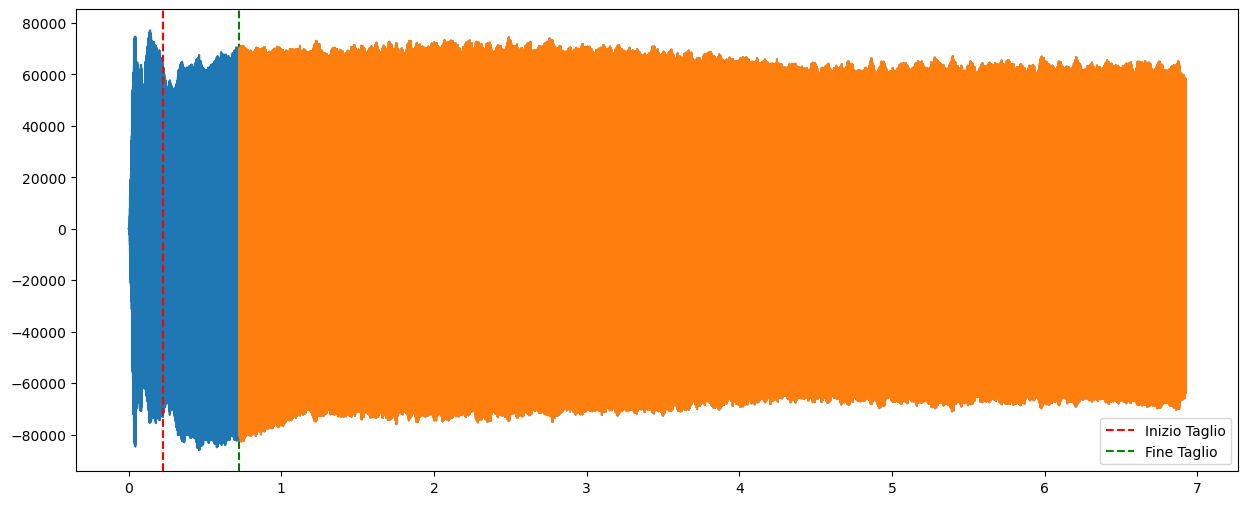

In [7]:
# visualizzo dove è il taglio sul segnale originale
plt.figure(figsize=(15,6))
plt.plot(time, array)
plt.axvline(x=inizio_taglio/rate, color='red', linestyle='--', label='Inizio Taglio')
plt.axvline(x=fine_taglio/rate, color='green', linestyle='--', label='Fine Taglio')
plt.legend()

#salvo il segnale solo dopo la riga di fine taglio, tutto il precedente è morto
array = array[fine_taglio:]
time = time[fine_taglio:]

plt.plot(time, array) 

plt.show()